# 05 - Layer B Outfit Rule Debug (Legacy)

Notebook này dùng để **đối chiếu luồng Layer B legacy**. Phần triển khai dài được thu gọn mặc định; các cell thực thi vẫn giữ output cần thiết cho debug.

> **Legacy reference:** Notebook này chỉ dùng để đối chiếu; hãy ưu tiên bản 05 V2.

### 05 - Layer B Outfit Rule Debug (Legacy)

- **Tác dụng chính:** Notebook này dùng để đối chiếu luồng Layer B legacy. Phần triển khai dài được thu gọn mặc định; các cell thực thi vẫn giữ output cần thiết cho debug.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `find_chatbot_fashion_root`, `BGE_M3_BASE_URL`, `BGE_M3_MODEL`, `build_layer_b_embedding_text`, `SimpleOllamaEmbeddings` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
import json

import sys

from pathlib import Path

import requests

from qdrant_client import QdrantClient

from qdrant_client.http.models import Distance, FieldCondition, Filter, MatchAny, VectorParams

from qdrant_client.models import PointStruct

def find_chatbot_fashion_root(start: Path | None = None) -> Path:
    """Xử lý bước `find chatbot fashion root` của pipeline.

    Args:
        start (Path | None): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        Path: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "app" / "config.py").exists():
            return candidate
    raise RuntimeError("Không tìm thấy thư mục gốc Chatbot_Fashion chứa app/config.py")


# Cấu hình BGE-M3 cho Layer B.
# Nếu chạy BGE-M3 trên VastAI, chỉ cần sửa URL bên dưới cho đúng endpoint Ollama public.
# VastAI SSH tunnel:
# ssh -N -L 11435:127.0.0.1:11434 root@124.60.192.12 -p 50044
# 11434 = Ollama local tren may ban; 11435 = tunnel sang Ollama tren VastAI.

BGE_M3_BASE_URL = "http://127.0.0.1:11435"

BGE_M3_MODEL = "bge-m3"

def build_layer_b_embedding_text(rule: dict) -> str:
    """Text semantic đem đi embed cho một rule Layer B.

    Args:
        rule (dict): Rule Layer B hoặc tập rule cần xử lý.

    Returns:
        str: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    return " ".join([
        str(rule.get("rule_key", "")),
        str(rule.get("phong_cach", "")),
        str(rule.get("boi_canh", "")),
        str(rule.get("ly_do_tu_van", "")),
    ]).strip()

class SimpleOllamaEmbeddings:
    """Wrapper tối giản gọi Ollama /api/embed hoặc /api/embeddings."""

    def __init__(self, base_url: str, model: str = "bge-m3", timeout: int = 120):
        """Xử lý bước `init` của pipeline.

        Args:
            base_url (str): Giá trị đầu vào phục vụ bước xử lý này.
            model (str): Giá trị đầu vào phục vụ bước xử lý này.
            timeout (int): Thời gian chờ tối đa cho thao tác bên ngoài.

        Returns:
            None: Không trả về; khởi tạo trạng thái cho đối tượng.
        """
        self.base_url = base_url.rstrip("/")
        self.model = model
        self.timeout = timeout

    def _embed_one(self, text: str) -> list[float]:
        # Ollama mới: /api/embed
        """Xử lý bước `embed one` của pipeline.

        Args:
            text (str): Nội dung truy vấn hoặc văn bản đầu vào.

        Returns:
            list[float]: Vector hoặc tensor biểu diễn dữ liệu đầu vào.
        """
        response = requests.post(
            f"{self.base_url}/api/embed",
            json={"model": self.model, "input": text},
            timeout=self.timeout,
        )
        if response.status_code == 404:
            # Ollama cũ: /api/embeddings
            response = requests.post(
                f"{self.base_url}/api/embeddings",
                json={"model": self.model, "prompt": text},
                timeout=self.timeout,
            )
        response.raise_for_status()
        data = response.json()
        if "embedding" in data:
            return data["embedding"]
        if "embeddings" in data and data["embeddings"]:
            return data["embeddings"][0]
        raise RuntimeError(f"Ollama không trả embedding hợp lệ: {data}")

    def embed_query(self, text: str) -> list[float]:
        return self._embed_one(text)

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        return [self._embed_one(text) for text in texts]

def check_ollama_embedding_server(base_url: str, model: str) -> None:
    """Xử lý bước `check ollama embedding server` của pipeline.

    Args:
        base_url (str): Giá trị đầu vào phục vụ bước xử lý này.
        model (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        None: Kết quả kiểm tra hoặc báo cáo chẩn đoán.
    """
    base_url = base_url.rstrip("/")
    print(f"[INFO] Kiểm tra Ollama: {base_url} | model={model}")
    response = requests.get(f"{base_url}/api/tags", timeout=15)
    response.raise_for_status()
    models = [item.get("name", "") for item in response.json().get("models", [])]
    print("[INFO] Models trên server:", models)
    model_found = model in models or f"{model}:latest" in models or any(name.startswith(f"{model}:") for name in models)
    if not model_found:
        print(f"[WARN] Không thấy model `{model}` trong /api/tags. Nếu embed lỗi, hãy pull/chạy model này trên VastAI.")

def normalize_product_metadata(doc):
    """Chuẩn hoá metadata ảnh sản phẩm về list path/url thuần.

    Args:
        doc (Any): Document hoặc danh sách Document cần xử lý.

    Returns:
        Any: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    images = doc.metadata.get("images", [])
    if isinstance(images, str):
        text = images.strip()
        if text.startswith(("[", "{")):
            try:
                images = json.loads(text)
            except json.JSONDecodeError:
                images = [images] if images else []
        else:
            images = [images] if images else []
    if isinstance(images, dict):
        images = [images]

    normalized_images = []
    for image in images or []:
        if isinstance(image, dict):
            value = (
                image.get("large")
                or image.get("hi_res")
                or image.get("url")
                or image.get("image_url")
                or image.get("path")
            )
        else:
            value = image
        value = str(value or "").strip()
        if value and value not in normalized_images:
            normalized_images.append(value)

    main_image = str(
        doc.metadata.get("image_url")
        or doc.metadata.get("main_image_relpath")
        or doc.metadata.get("main_image_path")
        or ""
    ).strip()
    if not main_image and normalized_images:
        main_image = normalized_images[0]

    doc.metadata["images"] = normalized_images
    doc.metadata["image_url"] = main_image
    return doc

def diversity_filter_documents(docs: list, max_docs: int = 3, max_per_brand: int = 2) -> list:
    """Xử lý bước `diversity filter documents` của pipeline.

    Args:
        docs (list): Document hoặc danh sách Document cần xử lý.
        max_docs (int): Document hoặc danh sách Document cần xử lý.
        max_per_brand (int): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list: Kết quả đã xử lý của hàm.
    """
    selected = []
    seen_product_ids = set()
    brand_counts = {}
    for doc in docs:
        doc = normalize_product_metadata(doc)
        product_id = str(doc.metadata.get("product_id", "")).strip().lower()
        brand = str(doc.metadata.get("brand", "")).strip().lower()
        if product_id and product_id in seen_product_ids:
            continue
        if brand and brand_counts.get(brand, 0) >= max_per_brand:
            continue
        selected.append(doc)
        if product_id:
            seen_product_ids.add(product_id)
        if brand:
            brand_counts[brand] = brand_counts.get(brand, 0) + 1
        if len(selected) >= max_docs:
            break
    return selected

required_from_previous_notebooks = []


In [139]:
CHATBOT_FASHION_DIR = globals().get("CHATBOT_FASHION_DIR", find_chatbot_fashion_root())

if str(CHATBOT_FASHION_DIR) not in sys.path:
    sys.path.insert(0, str(CHATBOT_FASHION_DIR))

from app.config import QDRANT_URL

from app.core.vector_store import get_product_vector_db

client = globals().get("client") or QdrantClient(url=QDRANT_URL, timeout=20, check_compatibility=False)

check_ollama_embedding_server(BGE_M3_BASE_URL, BGE_M3_MODEL)

rule_embeddings = SimpleOllamaEmbeddings(base_url=BGE_M3_BASE_URL, model=BGE_M3_MODEL)

print(f"[OK] Layer B embeddings đã sẵn sàng: {BGE_M3_BASE_URL} | model={BGE_M3_MODEL}")

missing = [name for name in required_from_previous_notebooks if name not in globals()]

if missing:
    print("[INFO] Cần chạy 01_environment_config_models.ipynb và 03_layer_a_text_retrieval_debug.ipynb trước để có:", ", ".join(missing))
else:
    print("[OK] Import và biến phụ thuộc đã sẵn sàng.")


[INFO] Kiểm tra Ollama: http://127.0.0.1:11435 | model=bge-m3
[INFO] Models trên server: ['qwen2.5vl:3b', 'qwen3:4b-instruct', 'bge-m3:latest']
[OK] Layer B embeddings đã sẵn sàng: http://127.0.0.1:11435 | model=bge-m3
[OK] Import và biến phụ thuộc đã sẵn sàng.


### BƯỚC 1: Nạp Knowledge Layer B

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `load_layer_b`, `layer_b_female`, `layer_b_male` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
def load_layer_b(file_path: str | Path) -> list:
    """Đọc file JSON chứa các quy tắc phối đồ của Layer B.

    Args:
        file_path (str | Path): Đường dẫn dữ liệu hoặc tệp cần xử lý.

    Returns:
        list: Kết quả đã xử lý của hàm.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)


In [140]:
layer_b_female = load_layer_b(CHATBOT_FASHION_DIR / "data" / "stylists" / "Layer_B_Female_Knowledge.json")

layer_b_male   = load_layer_b(CHATBOT_FASHION_DIR / "data" / "stylists" / "Layer_B_Male_Knowledge.json")

print(f"[OK] Layer B: {len(layer_b_female)} rule Nữ | {len(layer_b_male)} rule Nam")


[OK] Layer B: 880 rule Nữ | 416 rule Nam


### BƯỚC 1A: Kiểm Tra Knowledge Đầu Vào

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `REQUIRED_LAYER_B_FIELDS`, `split_rule_key`, `summarize_layer_b_data`, `female_stats`, `male_stats` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
REQUIRED_LAYER_B_FIELDS = {
    "rule_key", "phong_cach", "boi_canh", "dang_nguoi", "tone_da", "ly_do_tu_van", "goi_y_phoi_cung"
}

def split_rule_key(rule_key: str) -> tuple[str, str]:
    """Tách `rule_key` thành outfit slot và item archetype."""
    parts = str(rule_key or "").split("|", 1)
    outfit_slot = parts[0].strip()
    item_archetype = parts[1].strip() if len(parts) > 1 else ""
    return outfit_slot, item_archetype

def summarize_layer_b_data(data: list[dict], label: str, limit: int = 8) -> dict:
    """Xử lý bước `summarize layer b data` của pipeline.

    Args:
        data (list[dict]): Giá trị đầu vào phục vụ bước xử lý này.
        label (str): Giá trị đầu vào phục vụ bước xử lý này.
        limit (int): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    missing_rows = []
    category_counts = {}
    style_counts = {}
    context_counts = {}

    for idx, rule in enumerate(data):
        missing = sorted(REQUIRED_LAYER_B_FIELDS - set(rule))
        if missing:
            missing_rows.append({"index": idx, "missing": missing, "rule_key": rule.get("rule_key", "")})

        category, _ = split_rule_key(rule.get("rule_key", ""))
        category_counts[category] = category_counts.get(category, 0) + 1
        style = rule.get("phong_cach", "Không rõ")
        style_counts[style] = style_counts.get(style, 0) + 1
        context = rule.get("boi_canh", "Không rõ")
        context_counts[context] = context_counts.get(context, 0) + 1

    print(f"\n=== {label} Layer B knowledge ===")
    print(f"Tổng rule          : {len(data)}")
    print(f"Rule thiếu field   : {len(missing_rows)}")
    print("Top category       :", sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:limit])
    print("Top phong_cach     :", sorted(style_counts.items(), key=lambda x: x[1], reverse=True)[:limit])
    print("Top boi_canh       :", sorted(context_counts.items(), key=lambda x: x[1], reverse=True)[:limit])

    if missing_rows:
        print("\n[WARN] Một vài rule thiếu field:")
        for row in missing_rows[:5]:
            print(row)

    return {
        "total": len(data),
        "missing_rows": missing_rows,
        "category_counts": category_counts,
        "style_counts": style_counts,
        "context_counts": context_counts,
    }


In [141]:
female_stats = summarize_layer_b_data(layer_b_female, "Female")

male_stats = summarize_layer_b_data(layer_b_male, "Male")

print("\n=== Sample rule ===")

print(json.dumps(layer_b_female[0], ensure_ascii=False, indent=2))



=== Female Layer B knowledge ===
Tổng rule          : 880
Rule thiếu field   : 0
Top category       : [('Áo khoác ngoài', 206), ('Quần/Chân váy', 152), ('Giày dép', 136), ('Áo mặc trong (áo thun/sơ mi)', 122), ('Áo khoác nhẹ/Áo len', 104), ('Phụ kiện', 84), ('Túi xách', 59), ('Đầm/Jumpsuit', 17)]
Top phong_cach     : [('Casual', 281), ('Sweet-cool girl', 94), ('Sophisticated urban', 88), ('Minimalist neutral', 64), ('Vintage collegiate', 57), ('Vintage preppy', 49), ('Denim casual', 47), ('Sweet-cool', 29)]
Top boi_canh       : [('Thu đông – Xã hội', 121), ('Mùa đông – Xã hội', 108), ('Mùa đông – Công sở', 102), ('Thu đông – Ở nhà', 86), ('Thu đông – Học đường', 83), ('Thu đông – Công sở', 82), ('Mùa đông – Ở nhà', 74), ('Mùa đông – Học đường', 64)]

=== Male Layer B knowledge ===
Tổng rule          : 416
Rule thiếu field   : 0
Top category       : [('Áo khoác ngoài', 97), ('Giày dép', 76), ('Quần/Chân váy', 72), ('Phụ kiện', 52), ('Áo mặc trong (áo thun/sơ mi)', 51), ('Áo khoác nhẹ/Á

### BƯỚC 1B: Kiểm Tra Text Đưa Vào Embedding

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** các lệnh trong bước cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [142]:
print("=== Layer B Embedding Text Preview ===")
print(build_layer_b_embedding_text(layer_b_female[0]))


=== Layer B Embedding Text Preview ===
Áo khoác ngoài | soft lamb wool Sophisticated urban Mùa đông – Học đường Sự kết hợp giữa chất liệu mềm mại của lông cừu non với các lớp trang phục tinh tế tạo nên vẻ ngoài ấm áp, thanh lịch, rất phù hợp với không khí học đường mùa đông và phong cách đô thị sành điệu.


### BƯỚC 2: Index Rule Layer B Vào Qdrant

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `RECREATE_LAYER_B_COLLECTIONS`, `index_layer_b` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
RECREATE_LAYER_B_COLLECTIONS = False

def index_layer_b(data: list, collection_name: str, recreate: bool = False):
    """Index toàn bộ rule Layer B vào một collection Qdrant.

    Args:
        data (list): Giá trị đầu vào phục vụ bước xử lý này.
        collection_name (str): Tên collection Qdrant đích.
        recreate (bool): Cờ bật hoặc tắt hành vi tương ứng.

    Returns:
        Any: Kết quả đã xử lý của hàm.
    """
    existing = [c.name for c in client.get_collections().collections]
    if collection_name in existing:
        if recreate:
            client.delete_collection(collection_name)
            print(f"[RECREATE] Đã xoá collection cũ: {collection_name}")
        else:
            count = client.count(collection_name).count
            print(f"[SKIP] {collection_name} đã tồn tại ({count} rule) - bỏ qua index.")
            return

    client.create_collection(
        collection_name = collection_name,
        vectors_config  = VectorParams(size=1024, distance=Distance.COSINE),
    )

    points = []
    for i, rule in enumerate(data):
        # Dùng cùng công thức với app/core/vector_store.py để notebook và app không lệch index.
        text = build_layer_b_embedding_text(rule)
        vector = rule_embeddings.embed_query(text)
        points.append(PointStruct(id=i, vector=vector, payload=rule))

    client.upsert(collection_name=collection_name, points=points)
    print(f"[OK] Đã index {len(points)} rule vào {collection_name}")


In [143]:
index_layer_b(layer_b_female, "layer_b_female", recreate=RECREATE_LAYER_B_COLLECTIONS)

index_layer_b(layer_b_male,   "layer_b_male",   recreate=RECREATE_LAYER_B_COLLECTIONS)


[SKIP] layer_b_female đã tồn tại (880 rule) - bỏ qua index.
[SKIP] layer_b_male đã tồn tại (416 rule) - bỏ qua index.


### BƯỚC 2A: Kiểm Tra Collection Sau Khi Index

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `check_layer_b_collection`, `female_collection_info`, `male_collection_info` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
def check_layer_b_collection(collection_name: str) -> dict | None:
    """Xử lý bước `check layer b collection` của pipeline.

    Args:
        collection_name (str): Tên collection Qdrant đích.

    Returns:
        dict | None: Kết quả kiểm tra hoặc báo cáo chẩn đoán.
    """
    if not client.collection_exists(collection_name):
        print(f"[WARN] Chưa có collection: {collection_name}")
        return None

    count = client.count(collection_name).count
    info = client.get_collection(collection_name)
    vector_config = info.config.params.vectors

    print(f"\n=== {collection_name} ===")
    print(f"Points     : {count}")
    print(f"Vector size: {getattr(vector_config, 'size', None)}")
    print(f"Distance   : {getattr(vector_config, 'distance', None)}")
    return {"collection": collection_name, "count": count, "vector_config": vector_config}


In [144]:
female_collection_info = check_layer_b_collection("layer_b_female")

male_collection_info = check_layer_b_collection("layer_b_male")



=== layer_b_female ===
Points     : 880
Vector size: 1024
Distance   : Cosine

=== layer_b_male ===
Points     : 416
Vector size: 1024
Distance   : Cosine


### BƯỚC 3: Tìm Rule Chủ Đạo Và Rule Chi Tiết

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `iter_rule_values`, `wildcard_values`, `profile_match_values`, `normalize_gender_choice`, `layer_b_data_source` để các bước sau tiếp tục sử dụng.


In [145]:
def iter_rule_values(rule: dict, key: str) -> list[str]:
    """Xử lý bước `iter rule values` của pipeline.

    Args:
        rule (dict): Rule Layer B hoặc tập rule cần xử lý.
        key (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[str]: Kết quả đã xử lý của hàm.
    """
    value = rule.get(key)
    if value is None:
        return []
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    text = str(value).strip()
    return [text] if text else []


def wildcard_values(data_source: list[dict], key: str, base_value: str) -> list[str]:
    """Xử lý bước `wildcard values` của pipeline.

    Args:
        data_source (list[dict]): Giá trị đầu vào phục vụ bước xử lý này.
        key (str): Giá trị đầu vào phục vụ bước xử lý này.
        base_value (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[str]: Kết quả đã xử lý của hàm.
    """
    values = {base_value}
    for rule in data_source:
        for value in iter_rule_values(rule, key):
            if value == base_value or value.startswith(f"{base_value} "):
                values.add(value)
    return sorted(values)


def profile_match_values(data_source: list[dict], key: str, user_value: str, wildcard_base: str) -> list[str]:
    """Xử lý bước `profile match values` của pipeline.

    Args:
        data_source (list[dict]): Giá trị đầu vào phục vụ bước xử lý này.
        key (str): Giá trị đầu vào phục vụ bước xử lý này.
        user_value (str): Giá trị đầu vào phục vụ bước xử lý này.
        wildcard_base (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        list[str]: Kết quả đã xử lý của hàm.
    """
    return [user_value, *wildcard_values(data_source, key, wildcard_base)]


def normalize_gender_choice(gender: str | None = None) -> list[str]:
    """Trả về danh sách collection gender cần search.

    Args:
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.

    Returns:
        list[str]: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    value = str(gender or "all").strip().lower()
    if value in {"", "all", "auto", "both", "any", "unisex"}:
        return ["female", "male"]
    if value in {"female", "f", "nu", "n\u1eef", "woman", "women"}:
        return ["female"]
    if value in {"male", "m", "nam", "man", "men"}:
        return ["male"]
    raise ValueError("gender chỉ nên là 'female', 'male' hoặc 'all'")


def layer_b_data_source(gender: str) -> list[dict]:
    return layer_b_female if gender == "female" else layer_b_male


def annotate_layer_b_payload(payload: dict, gender: str, score: float | None = None) -> dict:
    """Xử lý bước `annotate layer b payload` của pipeline.

    Args:
        payload (dict): Dữ liệu trạng thái hoặc ngữ cảnh có cấu trúc.
        gender (str): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        score (float | None): Giá trị điểm, ngưỡng hoặc trọng số của thuật toán.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    row = dict(payload)
    row["_matched_gender"] = gender
    if score is not None:
        row["_score"] = float(score)
    return row


def build_profile_filter_for_gender(gender: str, profile: dict | None, fields: tuple[str, ...] = ("dang_nguoi", "tone_da")) -> Filter | None:
    """Xử lý bước `build profile filter for gender` của pipeline.

    Args:
        gender (str): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Dữ liệu trạng thái hoặc ngữ cảnh có cấu trúc.
        fields (tuple[str, ...]): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        Filter | None: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    if not profile:
        return None

    data_source = layer_b_data_source(gender)
    conditions = []
    if "dang_nguoi" in fields and profile.get("dang_nguoi"):
        # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
        conditions.append(FieldCondition(
            key="dang_nguoi",
            match=MatchAny(any=profile_match_values(data_source, "dang_nguoi", profile["dang_nguoi"], "M\u1ecdi v\u00f3c d\u00e1ng")),
        ))
    if "tone_da" in fields and profile.get("tone_da"):
        # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
        conditions.append(FieldCondition(
            key="tone_da",
            match=MatchAny(any=profile_match_values(data_source, "tone_da", profile["tone_da"], "M\u1ecdi tone da")),
        ))
    # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
    return Filter(must=conditions) if conditions else None


def query_layer_b_collections(
    query_vector: list[float],
    genders: list[str],
    profile: dict | None = None,
    fields: tuple[str, ...] = ("dang_nguoi", "tone_da"),
    limit_per_gender: int = 1,
    score_threshold: float = 0.50,
) -> list[dict]:
    """Xử lý bước `query layer b collections` của pipeline.

    Args:
        query_vector (list[float]): Nội dung truy vấn hoặc văn bản đầu vào.
        genders (list[str]): Giá trị đầu vào phục vụ bước xử lý này.
        profile (dict | None): Dữ liệu trạng thái hoặc ngữ cảnh có cấu trúc.
        fields (tuple[str, ...]): Giá trị đầu vào phục vụ bước xử lý này.
        limit_per_gender (int): Giới hạn số phần tử được xử lý hoặc trả về.
        score_threshold (float): Giá trị điểm, ngưỡng hoặc trọng số của thuật toán.

    Returns:
        list[dict]: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    candidates = []
    for gender in genders:
        # Truy vấn Qdrant để lấy candidate cùng score phục vụ debug.
        response = client.query_points(
            collection_name=f"layer_b_{gender}",
            query=query_vector,
            query_filter=build_profile_filter_for_gender(gender, profile, fields=fields),
            limit=limit_per_gender,
            score_threshold=score_threshold,
        )
        for point in response.points:
            candidates.append(annotate_layer_b_payload(point.payload, gender=gender, score=point.score))
    return sorted(candidates, key=lambda item: item.get("_score", 0.0), reverse=True)


def find_matching_rule(
    user_query: str,
    gender: str | None = "all",
    profile: dict | None = None,
) -> dict | None:
    """Tìm rule chủ đạo Layer B. gender='all' nghĩa là search cả female và male.

    Args:
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Dữ liệu trạng thái hoặc ngữ cảnh có cấu trúc.

    Returns:
        dict | None: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    genders = normalize_gender_choice(gender)
    query_vector = rule_embeddings.embed_query(user_query)

    results = query_layer_b_collections(
        query_vector=query_vector,
        genders=genders,
        profile=profile,
        fields=("dang_nguoi", "tone_da"),
        limit_per_gender=1,
        score_threshold=0.50,
    )

    if not results and profile and profile.get("tone_da") and profile.get("dang_nguoi"):
        results = query_layer_b_collections(
            query_vector=query_vector,
            genders=genders,
            profile=profile,
            fields=("dang_nguoi",),
            limit_per_gender=1,
            score_threshold=0.50,
        )

    if not results:
        results = query_layer_b_collections(
            query_vector=query_vector,
            genders=genders,
            profile=None,
            limit_per_gender=1,
            score_threshold=0.50,
        )

    return results[0] if results else None


### Hàm 2: Tìm Rule Chi Tiết Cho Từng Món

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `find_outfit_details` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
def find_outfit_details(base_rule: dict, gender: str | None = "all") -> dict:
    """Tìm rule chi tiết cho outfit dựa trên rule chủ đạo đã chọn.

    Args:
        base_rule (dict): Rule Layer B hoặc tập rule cần xử lý.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.

    Returns:
        dict: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    selected_gender = base_rule.get("_matched_gender") or normalize_gender_choice(gender)[0]
    collection = f"layer_b_{selected_gender}"
    outfit_rules = {}
    style_query = f"{base_rule['phong_cach']} {base_rule['boi_canh']}"
    data_source = layer_b_data_source(selected_gender)

    for category in base_rule.get("goi_y_phoi_cung", []):
        exact = [
            rule for rule in data_source
            if rule["rule_key"].startswith(category)
            and rule["phong_cach"] == base_rule["phong_cach"]
            and rule["boi_canh"] == base_rule["boi_canh"]
        ]
        if exact:
            outfit_rules[category] = annotate_layer_b_payload(exact[0], gender=selected_gender)
            continue

        query_vector = rule_embeddings.embed_query(f"{category} {style_query}")
        # Truy vấn Qdrant để lấy candidate cùng score phục vụ debug.
        raw_response = client.query_points(
            collection_name=collection,
            query=query_vector,
            limit=10,
            score_threshold=0.40,
        )
        category_results = [
            result for result in raw_response.points
            if result.payload["rule_key"].startswith(category)
        ]
        if category_results:
            best = category_results[0]
            outfit_rules[category] = annotate_layer_b_payload(best.payload, gender=selected_gender, score=best.score)

    return outfit_rules


In [146]:
print("[OK] Đã sẵn sàng: find_matching_rule | find_outfit_details")


[OK] Đã sẵn sàng: find_matching_rule | find_outfit_details


### BƯỚC 3A: Debug Output Layer B Từ Đầu Đến Cuối

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `layer_b_rule_row`, `print_rule_row`, `preview_layer_b_candidates`, `debug_layer_b_outfit` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [147]:
def layer_b_rule_row(rule: dict, rank: int | None = None, score: float | None = None) -> dict:
    """Xử lý bước `layer b rule row` của pipeline.

    Args:
        rule (dict): Rule Layer B hoặc tập rule cần xử lý.
        rank (int | None): Giá trị đầu vào phục vụ bước xử lý này.
        score (float | None): Giá trị điểm, ngưỡng hoặc trọng số của thuật toán.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    outfit_slot, item_archetype = split_rule_key(rule.get("rule_key", ""))
    row = {
        "rule_key": rule.get("rule_key", ""),
        "matched_gender": rule.get("_matched_gender", ""),
        "outfit_slot": outfit_slot,
        "item_archetype": item_archetype,
        "phong_cach": rule.get("phong_cach", ""),
        "boi_canh": rule.get("boi_canh", ""),
        "dang_nguoi": rule.get("dang_nguoi", ""),
        "tone_da": rule.get("tone_da", ""),
        "goi_y_phoi_cung": rule.get("goi_y_phoi_cung", []),
    }
    if rank is not None:
        row = {"rank": rank, **row}
    score = rule.get("_score", score)
    if score is not None:
        row["score"] = round(float(score), 4)
    return row


def print_rule_row(title: str, rule: dict | None) -> None:
    """Xử lý bước `print rule row` của pipeline.

    Args:
        title (str): Giá trị đầu vào phục vụ bước xử lý này.
        rule (dict | None): Rule Layer B hoặc tập rule cần xử lý.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    print(f"\n=== {title} ===")
    if not rule:
        print("[EMPTY] Không có rule")
        return
    print(json.dumps(layer_b_rule_row(rule), ensure_ascii=False, indent=2))
    reason = str(rule.get("ly_do_tu_van", "")).strip()
    if reason:
        print("Lý do:", reason[:500])


def preview_layer_b_candidates(user_query: str, gender: str | None = "all", limit: int = 5) -> list[dict]:
    """Xử lý bước `preview layer b candidates` của pipeline.

    Args:
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        limit (int): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        list[dict]: Kết quả đã xử lý của hàm.
    """
    genders = normalize_gender_choice(gender)
    query_vector = rule_embeddings.embed_query(user_query)
    candidates = []
    for gender_item in genders:
        # Truy vấn Qdrant để lấy candidate cùng score phục vụ debug.
        response = client.query_points(
            collection_name=f"layer_b_{gender_item}",
            query=query_vector,
            limit=limit,
            score_threshold=0.0,
        )
        for point in response.points:
            candidates.append(annotate_layer_b_payload(point.payload, gender=gender_item, score=point.score))

    candidates = sorted(candidates, key=lambda item: item.get("_score", 0.0), reverse=True)[:limit]
    rows = [layer_b_rule_row(rule, rank=i) for i, rule in enumerate(candidates, start=1)]
    print(f"\n=== Raw Layer B candidates: {', '.join('layer_b_' + g for g in genders)} ===")
    for row in rows:
        print(json.dumps(row, ensure_ascii=False, indent=2))
    return rows


def debug_layer_b_outfit(user_query: str, gender: str | None = "all", profile: dict | None = None) -> dict:
    """Xử lý bước `debug layer b outfit` của pipeline.

    Args:
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Dữ liệu trạng thái hoặc ngữ cảnh có cấu trúc.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    print("=== Layer B Debug Input ===")
    print("Query  :", user_query)
    print("Gender :", gender or "all")
    print("Profile:", profile or {})

    raw_candidates = preview_layer_b_candidates(user_query, gender=gender, limit=5)
    base_rule = find_matching_rule(user_query=user_query, gender=gender, profile=profile)
    print_rule_row("Selected base rule", base_rule)

    if not base_rule:
        return {"raw_candidates": raw_candidates, "base_rule": None, "outfit_rules": {}, "mapping_rows": []}

    outfit_rules = find_outfit_details(base_rule, gender=gender)
    print("\n=== Outfit detail rules ===")
    if not outfit_rules:
        print("[WARN] Không tìm được rule chi tiết cho các món phối cùng.")
    for category, rule in outfit_rules.items():
        _, item_archetype = split_rule_key(rule.get("rule_key", ""))
        layer_a_categories = get_layer_a_categories(category, item_archetype) if "get_layer_a_categories" in globals() else []
        print(json.dumps({
            "layer_b_category": category,
            "item_archetype": item_archetype,
            "layer_a_categories": layer_a_categories,
            "rule": layer_b_rule_row(rule),
        }, ensure_ascii=False, indent=2))

    mapping_rows = []
    for category, rule in outfit_rules.items():
        _, item_archetype = split_rule_key(rule.get("rule_key", ""))
        mapping_rows.append({
            "layer_b_category": category,
            "item_archetype": item_archetype,
            "matched_gender": rule.get("_matched_gender", base_rule.get("_matched_gender", "")),
            "layer_a_categories": get_layer_a_categories(category, item_archetype) if "get_layer_a_categories" in globals() else [],
        })

    return {
        "raw_candidates": raw_candidates,
        "base_rule": base_rule,
        "outfit_rules": outfit_rules,
        "mapping_rows": mapping_rows,
    }


### BƯỚC 4: Ánh Xạ Danh Mục Layer B -> Layer A

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `CATEGORY_MAPPING`, `PHU_KIEN_KEYWORD_ROUTER` để các bước sau tiếp tục sử dụng.


In [148]:
# Từ điển cơ bản: chuyển category Layer B sang tên kệ hàng của Layer A.
CATEGORY_MAPPING = {
    "Áo mặc trong (áo thun/sơ mi)": ["Áo"],
    "Áo khoác ngoài"              : ["Áo khoác"],
    "Áo khoác nhẹ/Áo len"         : ["Áo khoác"],
    "Quần/Chân váy"               : ["Quần", "Chân váy"],
    "Đầm/Jumpsuit"                : ["Đầm", "Jumpsuit"],
    "Giày dép"                    : ["Giày"],
    "Túi xách"                    : ["Túi xách"],
    "Phụ kiện"                    : None,  # Nhóm rộng, cần router phụ kiện bên dưới.
}

# Từ điển phụ kiện: đọc từ khóa tiếng Anh trong item_archetype để suy ra kệ hàng cụ thể.
PHU_KIEN_KEYWORD_ROUTER = {
    "Mũ"             : ["beret", "hat", "cap", "beanie", "fedora", "bucket", "brim", "flat cap", "earflap"],
    "Găng tay"       : ["gloves", "glove", "arm warmer"],
    "Kính mắt"       : ["glasses", "sunglasses", "sunglass"],
    "Đồng hồ"        : ["watch"],
    "Dây chuyền"     : ["necklace", "chain pendant", "chain"],
    "Bông tai"       : ["earring", "earrings"],
    "Vòng tay"       : ["bracelet"],
    "Nhẫn"           : ["ring"],
    "Ghim cài áo"    : ["brooch", "pin", "badge"],
    "Phụ kiện hỗ trợ": ["socks", "sock", "scarf", "tie", "belt", "bandana", "headband", "suspender"],
}


### Hàm 3: Map Category Layer B Sang Category Layer A

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `get_layer_a_categories` để các bước sau tiếp tục sử dụng.


In [149]:
def get_layer_a_categories(layer_b_category: str, item_archetype: str) -> list:
    """Chuyển tên category Layer B sang danh sách category Layer A có thể dùng để lọc sản phẩm.

    Args:
        layer_b_category (str): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        item_archetype (str): Bản ghi sản phẩm hoặc đối tượng đang xử lý.

    Returns:
        list: Kết quả đã xử lý của hàm.
    """
    if layer_b_category != "Phụ kiện":
        return CATEGORY_MAPPING.get(layer_b_category, [])

    archetype_lower = item_archetype.lower()
    for layer_a_cat, keywords in PHU_KIEN_KEYWORD_ROUTER.items():
        if any(keyword in archetype_lower for keyword in keywords):
            return [layer_a_cat]

    # Nếu không nhận diện được phụ kiện cụ thể, dùng nhóm dự phòng thay vì trả rỗng.
    return ["Phụ kiện hỗ trợ"]


### BƯỚC 4A: Kiểm Tra Mapping Category

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `mapping_test_cases`, `layer_b_debug_result` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
mapping_test_cases = [
    ("Áo mặc trong (áo thun/sơ mi)", "Áo thun basic"),
    ("Quần/Chân váy", "Quần jeans ống suông"),
    ("Giày dép", "Sneakers trắng"),
    ("Phụ kiện", "bucket hat"),
    ("Phụ kiện", "sunglasses"),
    ("Phụ kiện", "silver necklace"),
    ("Phụ kiện", "unknown accessory"),
]


In [151]:
print("=== Mapping test ===")

for layer_b_category, item_archetype in mapping_test_cases:
    print({
        "layer_b_category": layer_b_category,
        "item_archetype": item_archetype,
        "layer_a_categories": get_layer_a_categories(layer_b_category, item_archetype),
    })

# Ví dụ debug Layer B: đổi query/profile để kiểm tra các case khác.
# layer_b_debug_result = debug_layer_b_outfit(
#     user_query="mình muốn phối đồ đi học mùa đông phong cách thanh lịch",
#     gender="female",
#     profile={"dang_nguoi": "Dáng chữ nhật", "tone_da": "Da trung bình"},
# )

layer_b_debug_result = debug_layer_b_outfit(
    user_query="mình muốn phối đồ đi học mùa đông phong cách thanh lịch",
    gender="male",
    profile=None,
)


=== Mapping test ===
{'layer_b_category': 'Áo mặc trong (áo thun/sơ mi)', 'item_archetype': 'Áo thun basic', 'layer_a_categories': ['Áo']}
{'layer_b_category': 'Quần/Chân váy', 'item_archetype': 'Quần jeans ống suông', 'layer_a_categories': ['Quần', 'Chân váy']}
{'layer_b_category': 'Giày dép', 'item_archetype': 'Sneakers trắng', 'layer_a_categories': ['Giày']}
{'layer_b_category': 'Phụ kiện', 'item_archetype': 'bucket hat', 'layer_a_categories': ['Mũ']}
{'layer_b_category': 'Phụ kiện', 'item_archetype': 'sunglasses', 'layer_a_categories': ['Kính mắt']}
{'layer_b_category': 'Phụ kiện', 'item_archetype': 'silver necklace', 'layer_a_categories': ['Dây chuyền']}
{'layer_b_category': 'Phụ kiện', 'item_archetype': 'unknown accessory', 'layer_a_categories': ['Phụ kiện hỗ trợ']}


=== Layer B Debug Input ===
Query  : mình muốn phối đồ đi học mùa đông phong cách thanh lịch
Gender : male
Profile: {}

=== Raw Layer B candidates: layer_b_male ===
{
  "rank": 1,
  "rule_key": "Áo khoác nhẹ/Áo len | minimalist warm knit top",
  "matched_gender": "male",
  "outfit_slot": "Áo khoác nhẹ/Áo len",
  "item_archetype": "minimalist warm knit top",
  "phong_cach": "Quiet luxury old money",
  "boi_canh": "Mùa thu – Học đường",
  "dang_nguoi": [
    "Dáng quả lê",
    "Dáng quả táo",
    "Người ngoại cỡ"
  ],
  "tone_da": [
    "Da sáng",
    "Da trung bình"
  ],
  "goi_y_phoi_cung": [
    "Áo khoác nhẹ/Áo len",
    "Quần/Chân váy",
    "Giày dép"
  ],
  "score": 0.6578
}
{
  "rank": 2,
  "rule_key": "Áo khoác ngoài | autumn/winter casual varsity jacket",
  "matched_gender": "male",
  "outfit_slot": "Áo khoác ngoài",
  "item_archetype": "autumn/winter casual varsity jacket",
  "phong_cach": "Casual",
  "boi_canh": "Mùa xuân – Học đường",
  "dang_nguoi": [
    "Dáng quả lê",
    

### BƯỚC 5: Optional - Lấy Sản Phẩm Thật Từ Layer A

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `get_products_for_outfit` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
def get_products_for_outfit(
    item_archetype  : str,
    layer_b_category: str,
    phong_cach      : str,
    vdb,
    exclude_product_ids: set[str] | None = None,
    candidate_k: int = 40,
    max_docs: int = 3,
) -> list:
    """Tim san pham Layer A cho mot slot outfit.

    Args:
        item_archetype (str): Bản ghi sản phẩm hoặc đối tượng đang xử lý.
        layer_b_category (str): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        phong_cach (str): Giá trị đầu vào phục vụ bước xử lý này.
        vdb (Any): Client hoặc vector store dùng để truy vấn.
        exclude_product_ids (set[str] | None): Bản ghi sản phẩm hoặc đối tượng đang xử lý.
        candidate_k (int): Giá trị đầu vào phục vụ bước xử lý này.
        max_docs (int): Document hoặc danh sách Document cần xử lý.

    Returns:
        list: Kết quả đã xử lý của hàm.
    """
    exclude_product_ids = exclude_product_ids or set()
    target_categories = get_layer_a_categories(layer_b_category, item_archetype)

    search_filter = None
    if target_categories:
        # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
        search_filter = Filter(must=[
            # Lọc payload Qdrant theo ràng buộc đã suy ra trước khi xếp hạng.
            FieldCondition(
                key   = "metadata.category",
                match = MatchAny(any=target_categories)
            )
        ])

    query = f"{item_archetype} {phong_cach} {layer_b_category}"
    raw_results = vdb.similarity_search_with_score(query=query, k=candidate_k, filter=search_filter)

    strict_products = []
    fallback_products = []
    seen = set()
    for doc, score in raw_results:
        doc = normalize_product_metadata(doc)
        product_id = str(doc.metadata.get("product_id", "")).strip().lower()
        if product_id and product_id in exclude_product_ids:
            continue
        if product_id and product_id in seen:
            continue
        seen.add(product_id)

        if score >= 0.30:
            strict_products.append(doc)
        elif score >= 0.22:
            fallback_products.append(doc)

    selected = diversity_filter_documents(strict_products, max_docs=max_docs)
    if len(selected) < max_docs and fallback_products:
        selected_ids = {str(doc.metadata.get("product_id", "")).strip().lower() for doc in selected}
        more = [
            doc for doc in diversity_filter_documents(fallback_products, max_docs=max_docs)
            if str(doc.metadata.get("product_id", "")).strip().lower() not in selected_ids
        ]
        selected.extend(more[: max_docs - len(selected)])

    return selected


In [152]:
print("[OK] Đã sẵn sàng: CATEGORY_MAPPING | PHU_KIEN_KEYWORD_ROUTER | get_layer_a_categories | get_products_for_outfit")


[OK] Đã sẵn sàng: CATEGORY_MAPPING | PHU_KIEN_KEYWORD_ROUTER | get_layer_a_categories | get_products_for_outfit


### BƯỚC 5A: Optional - Debug Lấy Sản Phẩm Theo Outfit

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `debug_layer_b_to_layer_a_products`, `layer_a_product_debug` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
def debug_layer_b_to_layer_a_products(layer_b_result: dict, vdb=None) -> dict:
    """Xử lý bước `debug layer b to layer a products` của pipeline.

    Args:
        layer_b_result (dict): Giá trị đầu vào phục vụ bước xử lý này.
        vdb (Any): Client hoặc vector store dùng để truy vấn.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    vdb = vdb or globals().get("vector_db")
    if vdb is None:
        try:
            vdb = get_product_vector_db()
            globals()["vector_db"] = vdb
            print("[OK] Đã tự khởi tạo vector_db Layer A từ app.core.vector_store.")
        except Exception as exc:
            print(f"[SKIP] Chưa khởi tạo được vector_db Layer A: {exc}")
            print("Gợi ý: kiểm tra Qdrant, product collection và product embedding service/model; hoặc chạy notebook 03 để debug Layer A trước.")
            return {}

    base_rule = layer_b_result.get("base_rule")
    outfit_rules = layer_b_result.get("outfit_rules", {})
    if not base_rule:
        print("[SKIP] Không có base_rule để lấy sản phẩm.")
        return {}

    product_results = {}
    print("=== Layer B -> Layer A product retrieval ===")
    for category, rule in outfit_rules.items():
        _, item_archetype = split_rule_key(rule.get("rule_key", ""))
        products = get_products_for_outfit(
            item_archetype=item_archetype,
            layer_b_category=category,
            phong_cach=base_rule.get("phong_cach", ""),
            vdb=vdb,
        )
        product_results[category] = products
        print(f"\n--- {category} | {item_archetype} ---")
        if not products:
            print("[EMPTY] Không tìm được sản phẩm phù hợp.")
            continue
        for rank, doc in enumerate(products, start=1):
            doc = normalize_product_metadata(doc)
            print({
                "rank": rank,
                "product_id": doc.metadata.get("product_id", ""),
                "title": doc.metadata.get("title", ""),
                "category": doc.metadata.get("category", ""),
                "brand": doc.metadata.get("brand", ""),
                "image_url": doc.metadata.get("image_url", ""),
            })
    return product_results


In [153]:
layer_a_product_debug = debug_layer_b_to_layer_a_products(layer_b_debug_result)


=== Layer B -> Layer A product retrieval ===

--- Áo khoác nhẹ/Áo len | minimalist warm knit top ---
{'rank': 1, 'product_id': 'B08LNZTX46', 'title': 'Áo khoác Cardigan len nữ dáng dài Simply Couture', 'category': 'Áo khoác', 'brand': 'Simply Couture', 'image_url': 'images/B08LNZTX46_MAIN.jpg'}
{'rank': 2, 'product_id': 'B0793JQB9G', 'title': 'Áo khoác cardigan len nữ Alfani xẻ trước', 'category': 'Áo khoác', 'brand': 'Alfani', 'image_url': 'images/B0793JQB9G_MAIN.jpg'}
{'rank': 3, 'product_id': 'B01LJH9S64', 'title': 'Áo khoác nữ giả lông thú sang trọng dáng dài', 'category': 'Áo khoác', 'brand': 'GESELLIE', 'image_url': 'images/B01LJH9S64_MAIN.jpg'}

--- Quần/Chân váy | vintage utility trousers ---
{'rank': 1, 'product_id': 'B094NR2BJ1', 'title': 'Quần ống rộng vải cotton linen cạp chun rút dây fartey', 'category': 'Quần', 'brand': 'fartey', 'image_url': 'images/B094NR2BJ1_MAIN.jpg'}
{'rank': 2, 'product_id': 'B09ZKDDD3N', 'title': 'Quần lửng nữ vải Cotton Linen cạp chun', 'category'

### BƯỚC 6: Demo Output Dễ Nhìn Cho Layer B

- **Tác dụng chính:** Thực hiện bước đối chiếu luồng Layer B legacy.
- **Đầu vào (Input):** Cấu hình, dữ liệu hoặc đối tượng đã được chuẩn bị ở bước trước; tham số chi tiết nằm trong docstring của hàm.
- **Đầu ra (Output):** `USER_ITEM_HINTS`, `normalize_vi_text`, `infer_requested_item_from_query`, `apply_user_item_hint`, `product_image_candidates` cùng output debug như shape, ID, score hoặc trạng thái trung gian.


In [ ]:
import base64

import html

import mimetypes

from IPython.display import HTML, display

from app.core.image_search import resolve_main_image_path, search_products_by_image

from app.core.outfit import analyze_image_item_context, build_layer_b_query_from_image_context

USER_ITEM_HINTS = [
    (["ao khoac", "áo khoác", "khoac", "khoác", "jacket", "coat", "blazer"], "Áo khoác ngoài", "Áo khoác", "áo khoác trong ảnh"),
    (["ao", "áo", "shirt", "top", "tee", "t-shirt", "thun", "sơ mi", "so mi"], "Áo mặc trong (áo thun/sơ mi)", "Áo", "áo trong ảnh"),
    (["quan", "quần", "pants", "jeans", "trouser", "short"], "Quần/Chân váy", "Quần", "quần trong ảnh"),
    (["chan vay", "chân váy", "skirt"], "Quần/Chân váy", "Chân váy", "chân váy trong ảnh"),
    (["dam", "đầm", "váy liền", "vay lien", "dress", "jumpsuit"], "Đầm/Jumpsuit", "Đầm", "đầm hoặc jumpsuit trong ảnh"),
    (["giay", "giày", "dep", "dép", "sneaker", "loafer", "boot", "sandals"], "Giày dép", "Giày", "giày dép trong ảnh"),
    (["tui", "túi", "bag", "handbag", "tote"], "Túi xách", "Túi xách", "túi xách trong ảnh"),
    (["mu", "mũ", "kinh", "kính", "dong ho", "đồng hồ", "day chuyen", "dây chuyền", "nhan", "nhẫn", "phu kien", "phụ kiện"], "Phụ kiện", "Phụ kiện hỗ trợ", "phụ kiện trong ảnh"),
]

def normalize_vi_text(text: str) -> str:
    return str(text or "").lower().strip()

def infer_requested_item_from_query(user_query: str) -> dict | None:
    """Xử lý bước `infer requested item from query` của pipeline.

    Args:
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.

    Returns:
        dict | None: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    text = normalize_vi_text(user_query)
    for keywords, layer_b_category, layer_a_category, product_type in USER_ITEM_HINTS:
        if any(keyword in text for keyword in keywords):
            return {
                "layer_b_category": layer_b_category,
                "layer_a_category": layer_a_category,
                "product_type": product_type,
                "source": "user_query_hint",
            }
    return None

def apply_user_item_hint(item_context: dict, user_query: str) -> dict:
    """Xử lý bước `apply user item hint` của pipeline.

    Args:
        item_context (dict): Bản ghi sản phẩm hoặc đối tượng đang xử lý.
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    hint = infer_requested_item_from_query(user_query)
    if not hint:
        return item_context

    updated = dict(item_context)
    updated["retrieval_layer_a_category"] = item_context.get("layer_a_category", "")
    updated["retrieval_layer_b_category"] = item_context.get("layer_b_category", "")
    updated["retrieval_product_type"] = item_context.get("product_type", "")
    updated["layer_a_category"] = hint["layer_a_category"]
    updated["layer_b_category"] = hint["layer_b_category"]
    updated["product_type"] = hint["product_type"]
    updated["user_item_hint"] = hint
    return updated

def product_image_candidates(doc) -> list[str]:
    """Lay cac path/url anh co the co trong metadata san pham.

    Args:
        doc (Any): Document hoặc danh sách Document cần xử lý.

    Returns:
        list[str]: Kết quả đã xử lý của hàm.
    """
    doc = normalize_product_metadata(doc)
    values = [
        doc.metadata.get("main_image_path", ""),
        doc.metadata.get("image_url", ""),
        doc.metadata.get("main_image_relpath", ""),
        *doc.metadata.get("images", []),
    ]
    result = []
    for value in values:
        value = str(value or "").strip()
        if value and value not in result:
            result.append(value)
    return result

def resolve_product_image_file(value: str) -> Path | None:
    """Resolve path anh local bang PRODUCT_IMAGE_ROOT trong app.config.

    Args:
        value (str): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        Path | None: Dữ liệu đã được chuẩn hóa hoặc suy ra để dùng ở bước tiếp theo.
    """
    value = str(value or "").strip()
    if not value or value.startswith(("http://", "https://", "data:")):
        return None

    direct_path = Path(value)
    if direct_path.exists():
        return direct_path.resolve()

    image_path = resolve_main_image_path(value)
    if image_path.exists():
        return image_path.resolve()

    return None

def image_file_to_data_uri(image_path: Path) -> str:
    """Doi file anh local thanh data URI de tranh loi duong dan Windows co dau."""
    mime_type = mimetypes.guess_type(image_path.name)[0] or "image/jpeg"
    encoded = base64.b64encode(image_path.read_bytes()).decode("ascii")
    return f"data:{mime_type};base64,{encoded}"

def product_image_ref(doc) -> str:
    """Tra ve path/url ngan gon de in ra debug."""
    candidates = product_image_candidates(doc)
    return candidates[0] if candidates else ""

def product_image_src(doc) -> str:
    """Tra ve src dung de render anh trong notebook.

    Args:
        doc (Any): Document hoặc danh sách Document cần xử lý.

    Returns:
        str: Kết quả đã xử lý của hàm.
    """
    for value in product_image_candidates(doc):
        if value.startswith(("http://", "https://", "data:")):
            return value
        image_path = resolve_product_image_file(value)
        if image_path:
            return image_file_to_data_uri(image_path)
    return ""

def product_doc_row(doc, rank: int) -> dict:
    """Xử lý bước `product doc row` của pipeline.

    Args:
        doc (Any): Document hoặc danh sách Document cần xử lý.
        rank (int): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    doc = normalize_product_metadata(doc)
    price = doc.metadata.get("price", "")
    try:
        price = f"{int(price):,}".replace(",", ".")
    except Exception:
        pass
    return {
        "rank": rank,
        "product_id": doc.metadata.get("product_id", ""),
        "title": doc.metadata.get("title", ""),
        "category": doc.metadata.get("category", ""),
        "brand": doc.metadata.get("brand", ""),
        "price": price,
        "image_url": product_image_ref(doc),
    }

def display_product_cards(title: str, docs: list, limit: int = 3) -> None:
    """Hiển thị sản phẩm dạng card có ảnh ngay trong notebook.

    Args:
        title (str): Giá trị đầu vào phục vụ bước xử lý này.
        docs (list): Document hoặc danh sách Document cần xử lý.
        limit (int): Giới hạn số phần tử được xử lý hoặc trả về.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    rows = [
        (product_doc_row(doc, rank), product_image_src(doc))
        for rank, doc in enumerate(docs[:limit], start=1)
    ]
    if not rows:
        return

    cards = []
    for row, image_src in rows:
        image_url = html.escape(str(image_src), quote=True)
        title_text = html.escape(str(row.get("title", "Không có tên sản phẩm")))
        brand = html.escape(str(row.get("brand", "")))
        category = html.escape(str(row.get("category", "")))
        price = html.escape(str(row.get("price", ""))) or "Chưa có giá"
        product_id = html.escape(str(row.get("product_id", "")))
        rank = row.get("rank", "")

        if image_url:
            media = (
                f'<img src="{image_url}" '
                'style="width:100%;height:180px;object-fit:contain;background:#f7f7f7;border-radius:8px;" />'
            )
        else:
            media = (
                '<div style="height:180px;display:flex;align-items:center;justify-content:center;'
                'background:#f7f7f7;border-radius:8px;color:#777;font-size:13px;">Không có ảnh</div>'
            )

        cards.append(
            '<div style="border:1px solid #ddd;border-radius:8px;padding:10px;background:white;">'
            f'{media}'
            f'<div style="margin-top:8px;font-weight:700;font-size:13px;line-height:1.35;">#{rank} {title_text}</div>'
            f'<div style="margin-top:6px;color:#555;font-size:12px;line-height:1.35;">{brand}</div>'
            f'<div style="color:#777;font-size:12px;line-height:1.35;">{category}</div>'
            f'<div style="margin-top:6px;font-weight:700;color:#b42318;font-size:13px;">{price}</div>'
            f'<div style="margin-top:4px;color:#888;font-size:11px;">ID: {product_id}</div>'
            '</div>'
        )

    display(HTML(
        f'<h4 style="margin:12px 0 8px;">{html.escape(title)}</h4>'
        '<div style="display:grid;grid-template-columns:repeat(auto-fill,minmax(180px,1fr));gap:12px;">'
        + ''.join(cards) +
        '</div>'
    ))

def print_product_rows(title: str, docs: list, limit: int = 3, show_images: bool = True) -> None:
    """Xử lý bước `print product rows` của pipeline.

    Args:
        title (str): Giá trị đầu vào phục vụ bước xử lý này.
        docs (list): Document hoặc danh sách Document cần xử lý.
        limit (int): Giới hạn số phần tử được xử lý hoặc trả về.
        show_images (bool): Cờ bật hoặc tắt hành vi tương ứng.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    print(f"\n=== {title} ===")
    if not docs:
        print("[EMPTY] Không có sản phẩm phù hợp.")
        return
    for rank, doc in enumerate(docs[:limit], start=1):
        print(json.dumps(product_doc_row(doc, rank), ensure_ascii=False, indent=2))
    if show_images:
        display_product_cards(title, docs, limit=limit)

def print_layer_b_summary(layer_b_result: dict) -> None:
    """Xử lý bước `print layer b summary` của pipeline.

    Args:
        layer_b_result (dict): Giá trị đầu vào phục vụ bước xử lý này.

    Returns:
        None: Không trả về dữ liệu mới hoặc trả trạng thái sau khi hiển thị debug.
    """
    base_rule = layer_b_result.get("base_rule")
    outfit_rules = layer_b_result.get("outfit_rules", {})
    mapping_rows = layer_b_result.get("mapping_rows", [])

    print_rule_row("C. Rule chủ đạo Layer B được chọn", base_rule)

    print("\n=== D1. Rule chi tiết cho outfit ===")
    if not outfit_rules:
        print("[EMPTY] Không có rule chi tiết.")
    for layer_b_category, rule in outfit_rules.items():
        _, item_archetype = split_rule_key(rule.get("rule_key", ""))
        print(json.dumps({
            "layer_b_category": layer_b_category,
            "item_archetype": item_archetype,
            "matched_gender": rule.get("_matched_gender", ""),
            "phong_cach": rule.get("phong_cach", ""),
            "boi_canh": rule.get("boi_canh", ""),
            "ly_do_tu_van": rule.get("ly_do_tu_van", "")[:260],
        }, ensure_ascii=False, indent=2))

    print("\n=== D2. Mapping Layer B -> Layer A ===")
    if not mapping_rows:
        print("[EMPTY] Không có mapping rows.")
    for row in mapping_rows:
        print(json.dumps(row, ensure_ascii=False, indent=2))

def collect_layer_a_products(layer_b_result: dict, vdb=None) -> dict:
    """Xử lý bước `collect layer a products` của pipeline.

    Args:
        layer_b_result (dict): Giá trị đầu vào phục vụ bước xử lý này.
        vdb (Any): Client hoặc vector store dùng để truy vấn.

    Returns:
        dict: Các candidate đã truy hồi, lọc hoặc xếp hạng.
    """
    vdb = vdb or globals().get("vector_db")
    if vdb is None:
        vdb = get_product_vector_db()
        globals()["vector_db"] = vdb

    base_rule = layer_b_result.get("base_rule")
    outfit_rules = layer_b_result.get("outfit_rules", {})
    if not base_rule:
        return {}

    products_by_slot = {}
    used_product_ids = set()
    for layer_b_category, rule in outfit_rules.items():
        _, item_archetype = split_rule_key(rule.get("rule_key", ""))
        docs = get_products_for_outfit(
            item_archetype=item_archetype,
            layer_b_category=layer_b_category,
            phong_cach=base_rule.get("phong_cach", ""),
            vdb=vdb,
            exclude_product_ids=used_product_ids,
            candidate_k=40,
            max_docs=3,
        )
        products_by_slot[layer_b_category] = docs
        for doc in docs:
            product_id = str(doc.metadata.get("product_id", "")).strip().lower()
            if product_id:
                used_product_ids.add(product_id)
    return products_by_slot

def demo_layer_b_text_outfit(
    user_query: str,
    gender: str | None = "all",
    profile: dict | None = None,
) -> dict:
    """Xử lý bước `demo layer b text outfit` của pipeline.

    Args:
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Dữ liệu trạng thái hoặc ngữ cảnh có cấu trúc.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    print("# DEMO 1 - NGƯỜI DÙNG NHẬP TEXT")
    print("\n=== A. Input ===")
    print(json.dumps({
        "user_query": user_query,
        "gender": gender or "all",
        "profile": profile or {},
    }, ensure_ascii=False, indent=2))

    layer_b_result = debug_layer_b_outfit(user_query=user_query, gender=gender, profile=profile)
    print_layer_b_summary(layer_b_result)

    print("\n=== E. Sản phẩm thật Layer A ===")
    try:
        products_by_slot = collect_layer_a_products(layer_b_result)
        for layer_b_category, docs in products_by_slot.items():
            print_product_rows(layer_b_category, docs, show_images=True)
    except Exception as exc:
        print(f"[WARN] Chưa lấy được sản phẩm Layer A: {exc}")
        products_by_slot = {}

    return {"layer_b": layer_b_result, "products_by_slot": products_by_slot}

IMAGE_QUERY_PATH = r"D:\KHÓA LUẬN\WORKSPACE\Chatbot_Fashion\English\multimodal_rag\TestImages\test1.jpg"  # Điền path ảnh local vào đây.

IMAGE_OUTFIT_QUERY = "Có gợi ý phối đồ nào với cái áo này cho mùa hè sắp tới không"

IMAGE_OUTFIT_GENDER = "all"

IMAGE_OUTFIT_PROFILE = {"dang_nguoi": "Mọi vóc dáng", "tone_da": "Da trung bình"}

def demo_layer_b_image_outfit(
    image_path: str | Path,
    user_query: str = "món này phối sao",
    gender: str | None = "all",
    profile: dict | None = None,
) -> dict:
    """Xử lý bước `demo layer b image outfit` của pipeline.

    Args:
        image_path (str | Path): Đường dẫn dữ liệu hoặc tệp cần xử lý.
        user_query (str): Nội dung truy vấn hoặc văn bản đầu vào.
        gender (str | None): Ràng buộc phân loại dùng để lọc hoặc xếp hạng.
        profile (dict | None): Dữ liệu trạng thái hoặc ngữ cảnh có cấu trúc.

    Returns:
        dict: Kết quả đã xử lý của hàm.
    """
    image_path = Path(image_path)
    print("# DEMO 2 - NGƯỜI DÙNG NHẬP ẢNH")
    print("\n=== A. Input ===")
    print(json.dumps({
        "image_path": str(image_path),
        "user_query": user_query,
        "gender": gender or "all",
        "profile": profile or {},
    }, ensure_ascii=False, indent=2))

    if not image_path.exists():
        print("[SKIP] IMAGE_QUERY_PATH chưa tồn tại. Hãy điền đường dẫn ảnh local rồi chạy lại cell này.")
        return {}

    image_docs = search_products_by_image(image_path)
    print_product_rows("B1. Sản phẩm giống ảnh đầu vào", image_docs, limit=5, show_images=True)

    raw_item_context = analyze_image_item_context(image_docs)
    item_context = apply_user_item_hint(raw_item_context, user_query)
    layer_b_query = build_layer_b_query_from_image_context(item_context, user_query, profile)
    print("\n=== B2. Ngữ cảnh món đồ suy ra từ ảnh ===")
    print(json.dumps(item_context, ensure_ascii=False, indent=2))
    print("\nQuery gửi sang Layer B:", layer_b_query)

    layer_b_result = debug_layer_b_outfit(user_query=layer_b_query, gender=gender, profile=profile)
    print_layer_b_summary(layer_b_result)

    print("\n=== E. Sản phẩm thật Layer A ===")
    try:
        products_by_slot = collect_layer_a_products(layer_b_result)
        for layer_b_category, docs in products_by_slot.items():
            print_product_rows(layer_b_category, docs, show_images=True)
    except Exception as exc:
        print(f"[WARN] Chưa lấy được sản phẩm Layer A: {exc}")
        products_by_slot = {}

    return {
        "image_docs": image_docs,
        "item_context": item_context,
        "layer_b_query": layer_b_query,
        "layer_b": layer_b_result,
        "products_by_slot": products_by_slot,
    }


# DEMO 1 - NGƯỜI DÙNG NHẬP TEXT

=== A. Input ===
{
  "user_query": "mình muốn phối đồ đi học mùa hè phong cách đơn giản ",
  "gender": "female",
  "profile": {
    "dang_nguoi": "Dáng chữ nhật",
    "tone_da": "Da trung bình"
  }
}
=== Layer B Debug Input ===
Query  : mình muốn phối đồ đi học mùa hè phong cách đơn giản 
Gender : female
Profile: {'dang_nguoi': 'Dáng chữ nhật', 'tone_da': 'Da trung bình'}

=== Raw Layer B candidates: layer_b_female ===
{
  "rank": 1,
  "rule_key": "Áo khoác ngoài | minimalist basic green jacket",
  "matched_gender": "female",
  "outfit_slot": "Áo khoác ngoài",
  "item_archetype": "minimalist basic green jacket",
  "phong_cach": "Casual",
  "boi_canh": "Mùa thu – Học đường",
  "dang_nguoi": [
    "Dáng đồng hồ cát",
    "Dáng chữ nhật"
  ],
  "tone_da": [
    "Mọi tone da"
  ],
  "goi_y_phoi_cung": [
    "Áo mặc trong (áo thun/sơ mi)",
    "Quần/Chân váy",
    "Giày dép"
  ],
  "score": 0.6542
}
{
  "rank": 2,
  "rule_key": "Áo mặc trong (áo thun/sơ mi) 


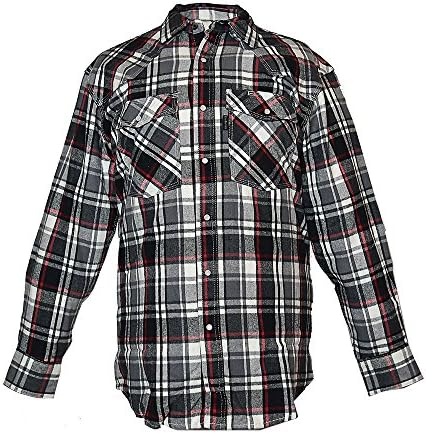
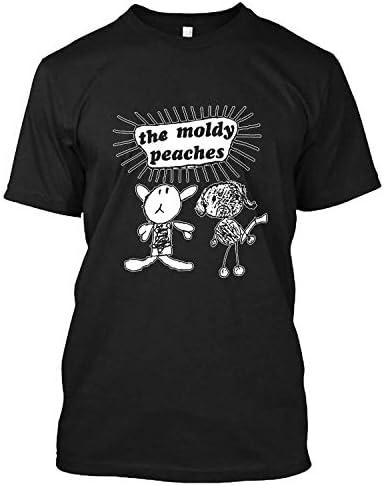
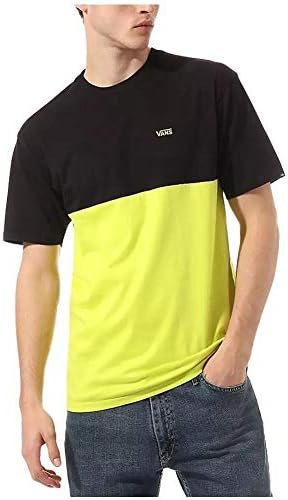


=== Quần/Chân váy ===
{
  "rank": 1,
  "product_id": "B09WM9XCHL",
  "title": "Quần short túi hộp OCHENTA cho nữ",
  "category": "Quần",
  "brand": "OCHENTA",
  "price": "719.760",
  "image_url": "images/B09WM9XCHL_MAIN.jpg"
}
{
  "rank": 2,
  "product_id": "pdp-i3303369323",
  "title": "Chân váy ngắn chấm bi chữ A",
  "category": "Chân váy",
  "brand": "Cantonstory",
  "price": "388.960",
  "image_url": "images/pdp-i3303369323_MAIN.jpg"
}
{
  "rank": 3,
  "product_id": "pdp-i13338752828",
  "title": "Quần Váy Ngắn Cho Bé Gái",
  "category": "Chân váy",
  "brand": "Minipeace",
  "price": "691.900",
  "image_url": "images/pdp-i13338752828_MAIN.jpg"
}



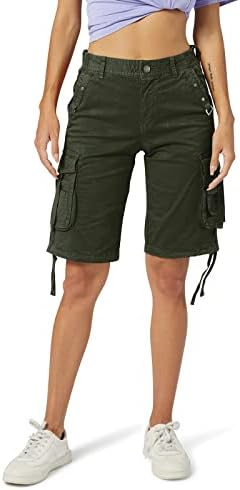
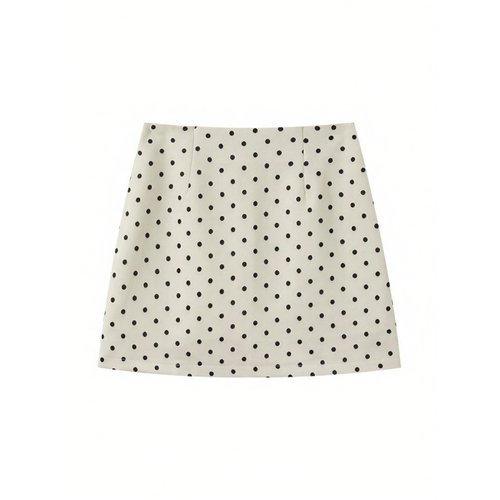
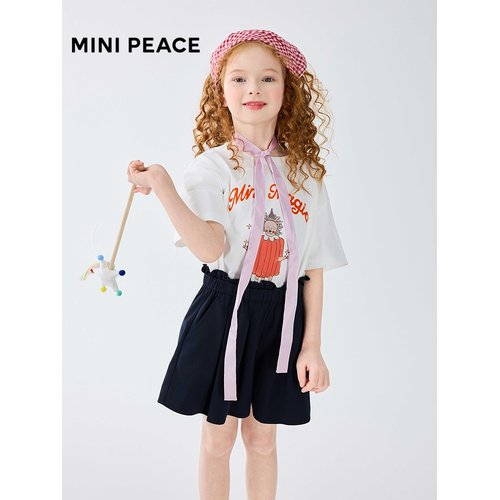


=== Giày dép ===
{
  "rank": 1,
  "product_id": "B079RLX12Q",
  "title": "Giày da nam Earth Hawk",
  "category": "Giày",
  "brand": "Earth",
  "price": "1.560.000",
  "image_url": "images/B079RLX12Q_MAIN.jpg"
}
{
  "rank": 2,
  "product_id": "B0B1N1TPVP",
  "title": "Dép sục casual Savoy màu nâu",
  "category": "Giày",
  "brand": "Easy Spirit",
  "price": "1.199.760",
  "image_url": "images/B0B1N1TPVP_MAIN.jpg"
}
{
  "rank": 3,
  "product_id": "pdp-i2374078325",
  "title": "Xăng đan đế xuồng thời trang",
  "category": "Giày",
  "brand": "Không có thương hiệu",
  "price": "409.999",
  "image_url": "images/pdp-i2374078325_MAIN.jpg"
}



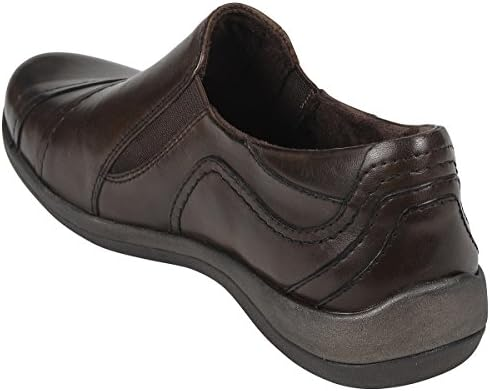
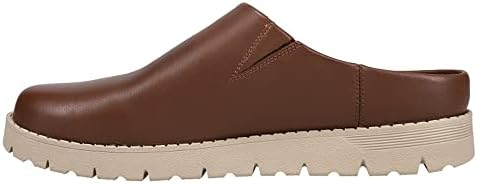
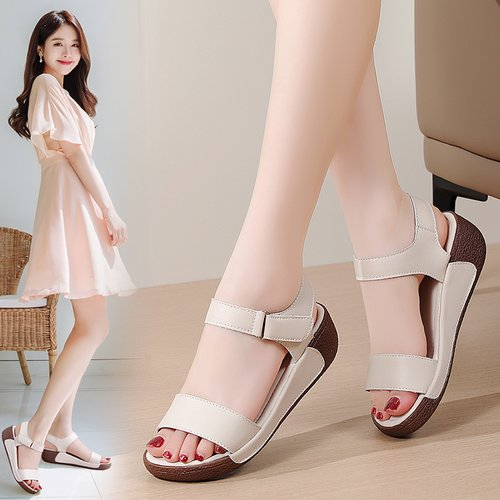

# DEMO 2 - NGƯỜI DÙNG NHẬP ẢNH

=== A. Input ===
{
  "image_path": "D:\\KHÓA LUẬN\\WORKSPACE\\Chatbot_Fashion\\English\\multimodal_rag\\TestImages\\test1.jpg",
  "user_query": "Có gợi ý phối đồ nào với cái áo này cho mùa hè sắp tới không",
  "gender": "all",
  "profile": {
    "dang_nguoi": "Mọi vóc dáng",
    "tone_da": "Da trung bình"
  }
}


FashionCLIP image embed:   0%|          | 0/1 [00:00<?, ?it/s]


=== B1. Sản phẩm giống ảnh đầu vào ===
{
  "rank": 1,
  "product_id": "pdp-i1858009086",
  "title": "Combo 5 áo lót nam ba lỗ/cộc tay cotton",
  "category": "Đồ lót",
  "brand": "Không có thương hiệu",
  "price": "29.000",
  "image_url": "/workspace/Chatbot_Fashion/data/images/pdp-i1858009086_MAIN.jpg"
}
{
  "rank": 2,
  "product_id": "pdp-i1686827430",
  "title": "Áo lót nam Đông Xuân",
  "category": "Đồ lót",
  "brand": "Đông Xuân",
  "price": "55.000",
  "image_url": "/workspace/Chatbot_Fashion/data/images/pdp-i1686827430_MAIN.jpg"
}
{
  "rank": 3,
  "product_id": "pdp-i532414124",
  "title": "Áo lót nam cổ tim",
  "category": "Đồ lót",
  "brand": "Không có thương hiệu",
  "price": "65.000",
  "image_url": "/workspace/Chatbot_Fashion/data/images/pdp-i532414124_MAIN.jpg"
}



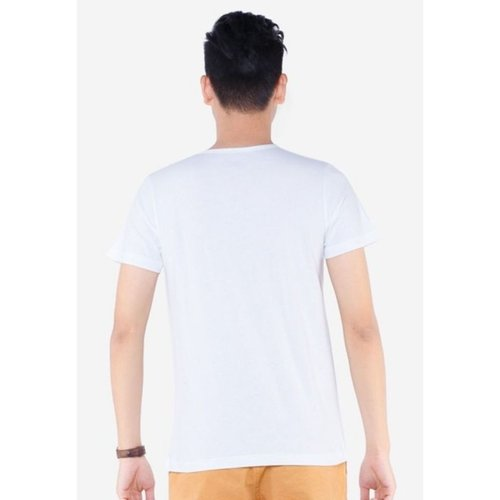
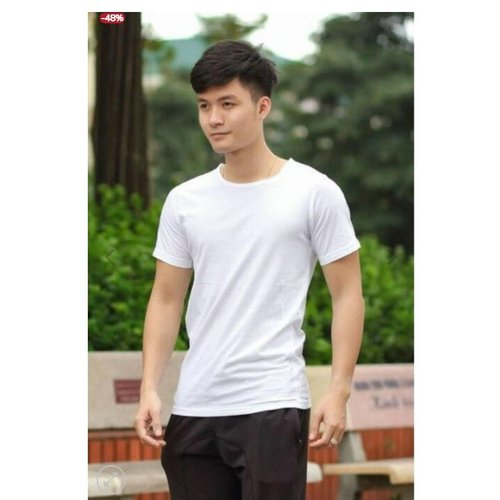
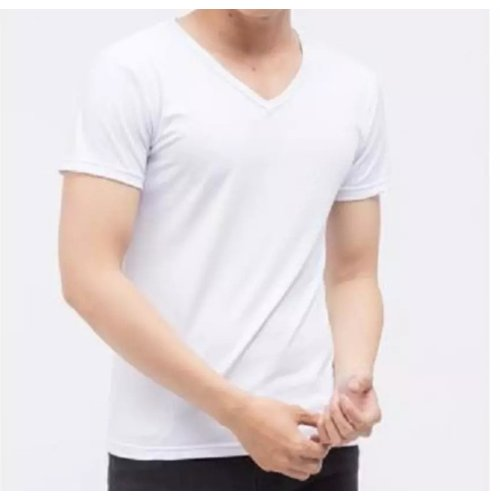


=== B2. Ngữ cảnh món đồ suy ra từ ảnh ===
{
  "layer_a_category": "Áo",
  "layer_b_category": "Áo mặc trong (áo thun/sơ mi)",
  "department": "Nam",
  "product_type": "áo trong ảnh",
  "color": "",
  "material": "",
  "pattern": "",
  "season": "",
  "occasion": "",
  "top_score": 0.8036,
  "score_gap": 0.0365,
  "category_agreement": 1.0,
  "confidence": "high",
  "confidence_score": 0.8912,
  "needs_vlm": false,
  "source": "image_retrieval_metadata",
  "retrieval_layer_a_category": "Đồ lót",
  "retrieval_layer_b_category": "Phụ kiện",
  "retrieval_product_type": "Combo 5 áo lót nam ba lỗ/cộc tay cotton",
  "user_item_hint": {
    "layer_b_category": "Áo mặc trong (áo thun/sơ mi)",
    "layer_a_category": "Áo",
    "product_type": "áo trong ảnh",
    "source": "user_query_hint"
  }
}

Query gửi sang Layer B: Phối đồ với Áo mặc trong (áo thun/sơ mi) áo trong ảnh cho Nam Có gợi ý phối đồ nào với cái áo này cho mùa hè sắp tới không
=== Layer B Debug Input ===
Query  : Phối đồ với Áo mặ


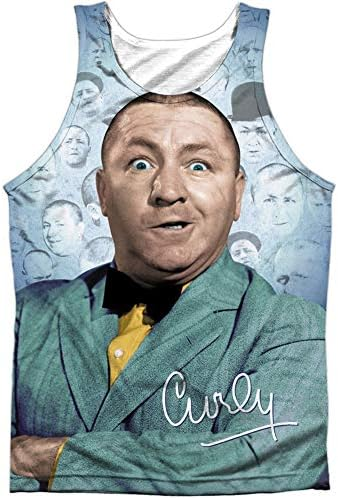
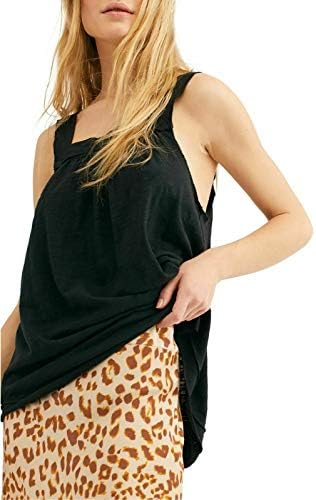
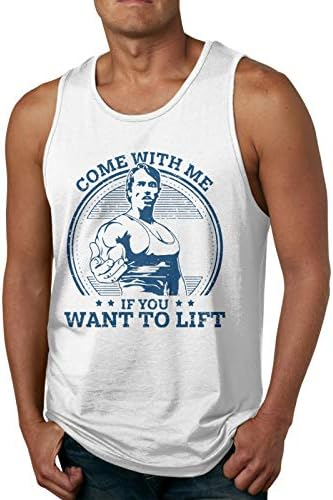


=== Quần/Chân váy ===
{
  "rank": 1,
  "product_id": "B0B586GBN7",
  "title": "Chân váy xếp ly dáng xòe kèm quần bảo hộ SOUGAO",
  "category": "Chân váy",
  "brand": "sougao",
  "price": "191.760",
  "image_url": "images/B0B586GBN7_MAIN.jpg"
}
{
  "rank": 2,
  "product_id": "pdp-i3301220256",
  "title": "Chân Váy Thời Trang Nữ",
  "category": "Chân váy",
  "brand": "Mixd",
  "price": "330.280",
  "image_url": "images/pdp-i3301220256_MAIN.jpg"
}
{
  "rank": 3,
  "product_id": "pdp-i13359342172",
  "title": "Chân váy phong cách Lolita",
  "category": "Chân váy",
  "brand": "Không có thương hiệu",
  "price": "1.729.000",
  "image_url": "images/pdp-i13359342172_MAIN.jpg"
}



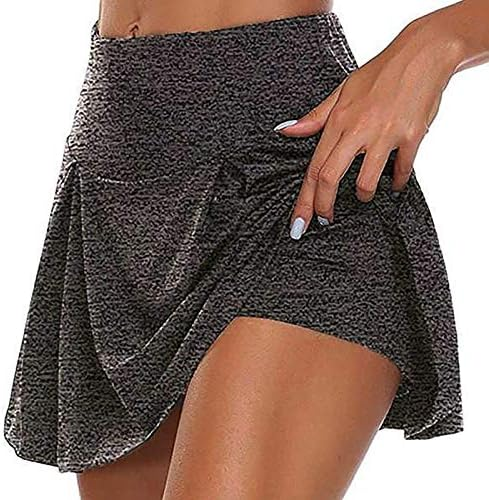
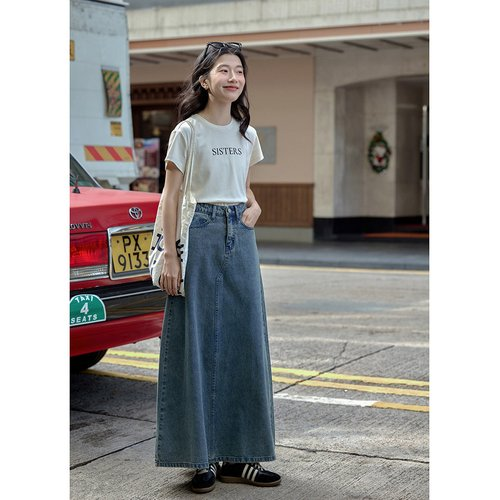
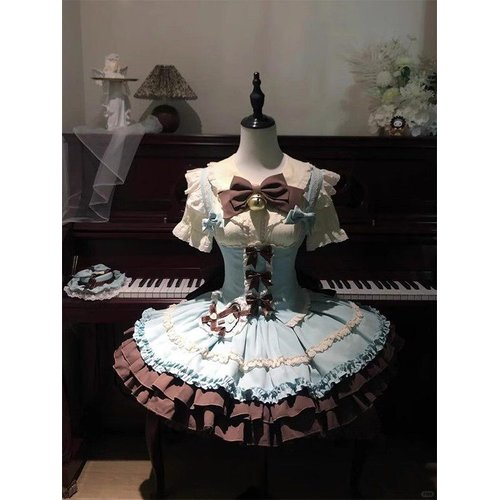


=== Giày dép ===
{
  "rank": 1,
  "product_id": "B018WL5P5S",
  "title": "Giày bệt Star Wars C3P0",
  "category": "Giày",
  "brand": "Irregular Choice",
  "price": "3.600.000",
  "image_url": "images/B018WL5P5S_MAIN.jpg"
}
{
  "rank": 2,
  "product_id": "B01MXXW91L",
  "title": "Giày búp bê Star Wars C3P0",
  "category": "Giày",
  "brand": "Irregular Choice",
  "price": "3.600.000",
  "image_url": "images/B01MXXW91L_MAIN.jpg"
}
{
  "rank": 3,
  "product_id": "pdp-i13337742724",
  "title": "Giày Sneakers Dạo Phố Unisex",
  "category": "Giày",
  "brand": "adidas",
  "price": "867.000",
  "image_url": "images/pdp-i13337742724_MAIN.jpg"
}



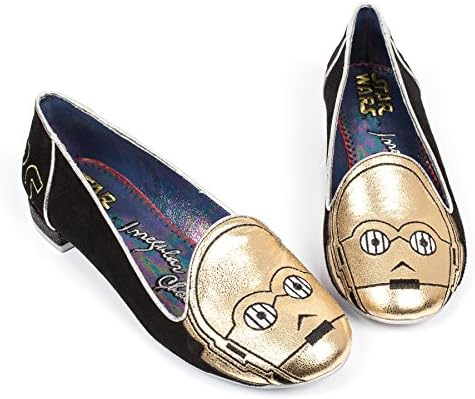
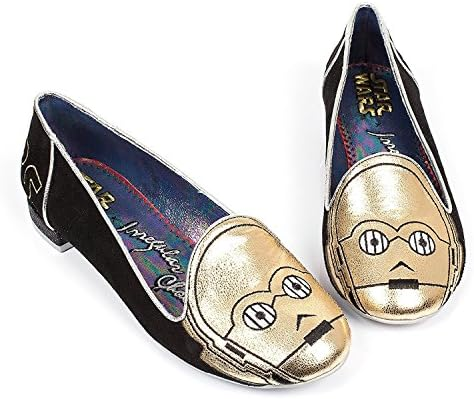
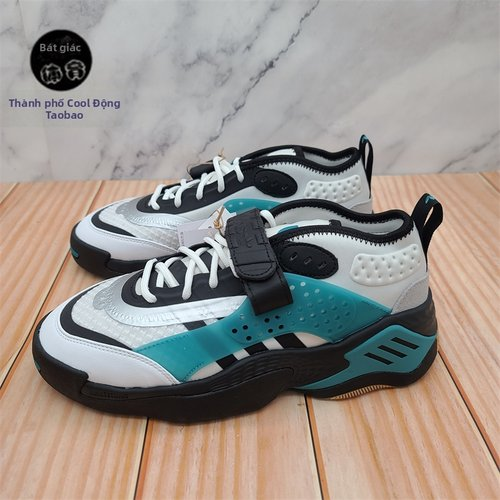

In [159]:
text_demo_result = demo_layer_b_text_outfit(
    user_query="mình muốn phối đồ đi học mùa hè phong cách đơn giản ",
    gender="female",
    profile={"dang_nguoi": "Dáng chữ nhật", "tone_da": "Da trung bình"},
)

if IMAGE_QUERY_PATH.strip():
    image_demo_result = demo_layer_b_image_outfit(
        image_path=IMAGE_QUERY_PATH,
        user_query=IMAGE_OUTFIT_QUERY,
        gender=IMAGE_OUTFIT_GENDER,
        profile=IMAGE_OUTFIT_PROFILE,
    )
else:
    print("[SKIP] Điền IMAGE_QUERY_PATH rồi chạy lại cell để demo case người dùng nhập ảnh.")
